# Indie Games Business Insight
Tujuan : Menganalisis data bisnis indie game.

## 1.Data Overview
Tujuan : Menggambarkan secara umum data yang digunakan.

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("indie_game_data.csv")

df.head()

,game_id,dev_cost,market_cost,price_tag,player_base,review_score,avg_playtime,is_profitable
0,ID_001,143635.03,95317.86,14.99,167473,73.1,4.9,1
1,ID_002,133427.15,18572.35,14.99,34177,47.9,8.2,1
2,ID_003,181189.11,46034.78,0.00,94072,45.1,39.0,0
3,ID_004,72651.61,63746.67,19.99,104202,55.7,24.7,1
4,ID_005,66262.90,95144.13,19.99,152389,18.6,10.0,1


In [125]:
df.tail()

,game_id,dev_cost,market_cost,price_tag,player_base,review_score,avg_playtime,is_profitable
495,ID_496,200787.53,69840.58,19.99,116637,72.9,26.8,1
496,ID_497,112770.03,66790.40,29.99,95406,53.2,29.6,1
497,ID_498,169632.09,93241.66,0.00,189519,53.0,11.1,0
498,ID_499,207843.83,45507.84,19.99,82108,95.5,32.4,1
499,ID_500,251494.73,61241.60,19.99,101666,100.0,4.5,1


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   game_id        500 non-null    object 
 1   dev_cost       500 non-null    float64
 2   market_cost    500 non-null    float64
 3   price_tag      500 non-null    float64
 4   player_base    500 non-null    int64  
 5   review_score   500 non-null    float64
 6   avg_playtime   500 non-null    float64
 7   is_profitable  500 non-null    int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 31.4+ KB


In [127]:
df.isnull().sum()

game_id          0
dev_cost         0
market_cost      0
price_tag        0
player_base      0
review_score     0
avg_playtime     0
is_profitable    0
dtype: int64

## 2. Materi : The Honest Explorer
Tujuan : Mencari keanehan dan menemukan solusi relevan.

In [128]:
# MEAN
avg_of_playtime = df["avg_playtime"].mean()
print("Rata-rata: ", avg_of_playtime)

Rata-rata:  47.60859999999999


Ini sedikit aneh karena jika melihat data overview, mayoritas data avg_playtime tidak menyentuh angka 40.

<Axes: xlabel='avg_playtime'>

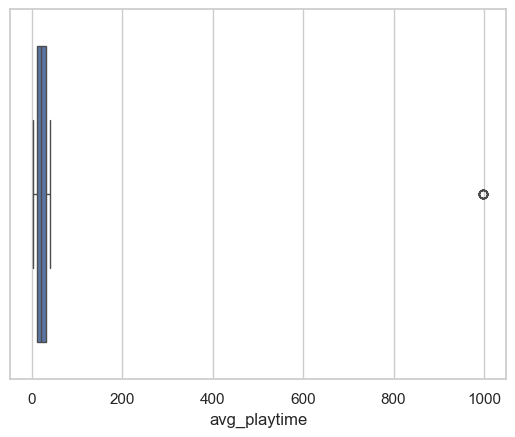

In [151]:
sns.set_theme(style="whitegrid")
sns.boxplot(x=df["avg_playtime"])

Setelah kita visualisasi, ternyata ada semacam keanehan pada data, yaitu terdapat average playtime hingga mendekati angka 1000. Hal ini tidak masuk akal mengingat data average playtime punya format jam per minggu.

Kita coba cek dengan median.

In [130]:
# MEDIAN
median_avg_playtime = df["avg_playtime"].median()
print("Median: ", median_avg_playtime)

Median:  20.15


Kita bisa melihat angka median yang jauh lebih normal. Perbedaan hal ini disebabkan oleh adanya data anomali/aneh yang ada di dataset. Sebelumnya, dataset generator yang telah dibuat sengaja memberikan semacam glitch agar terdapat data dengan avg_playtime dengan angka yang besar. Hal ini memicu peningkatan angka rata-rata dan membuatnya tidak relevan untuk menjadi dasar analisis. Sehingga, penggunaan median jauh lebih mewakili kondisi pemain saat ini.

## 3. Materi: The Profitability Deep Dive
Tujuan : Membandingkan total game yang mendapat profit dan tidak.

In [131]:
profitable_game = df["is_profitable"].sum() / len(df) * 100
print(profitable_game, "% : game mendapatkan keuntungan")

81.2 % : game mendapatkan keuntungan


In [132]:
nonprofitable_game = (len(df) - df["is_profitable"].sum()) / len(df) * 100
print(nonprofitable_game, "% : game mengalami kerugian")

18.8 % : game mengalami kerugian


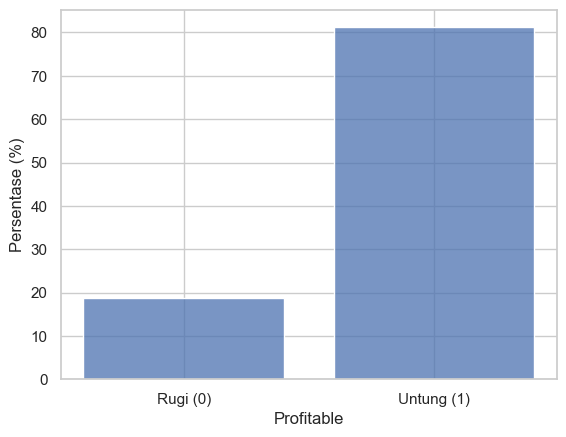

In [133]:
sns.histplot(data=df, x=df["is_profitable"], stat="percent", discrete=True, shrink=0.8)

plt.xticks([0, 1], labels=['Rugi (0)', 'Untung (1)'])
plt.xlabel("Profitable")
plt.ylabel("Persentase (%)")
plt.show()

Data menunjukkan bahwa sebagian besar game mendapatkan keuntungan dari penjualan mereka.

## 4. Materi : Correlation
Tujuan : Faktor yang paling mempengaruhi untung/rugi sebuah game.

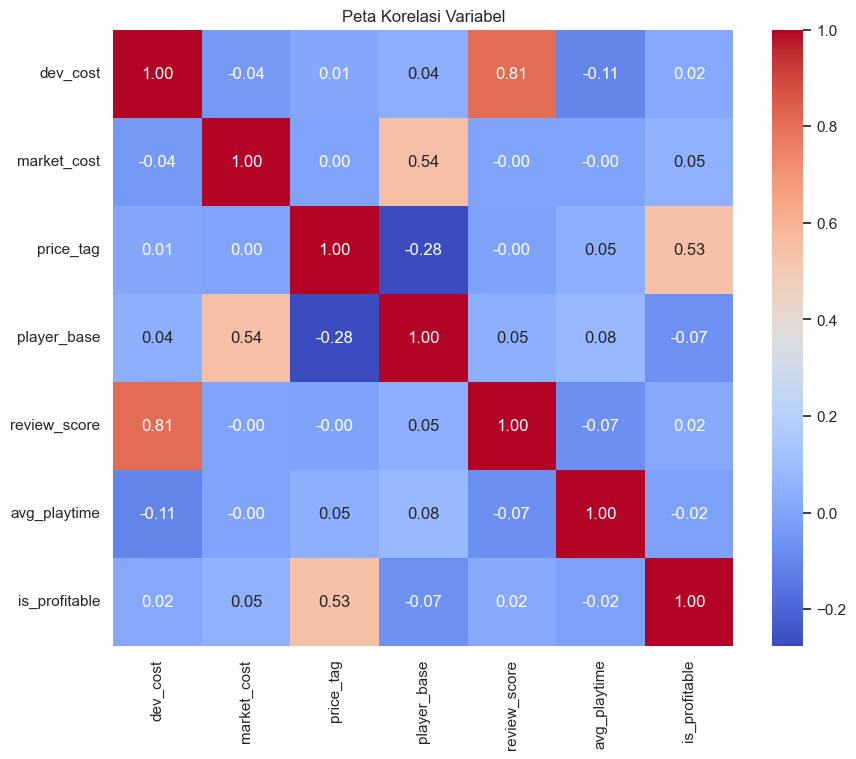

In [147]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Peta Korelasi Variabel")
plt.show()

In [134]:
df.corr(numeric_only=True)

,dev_cost,market_cost,price_tag,player_base,review_score,avg_playtime,is_profitable
dev_cost,1.000000,-0.036564,0.009278,0.041601,0.807515,-0.106977,0.017852
market_cost,-0.036564,1.000000,0.001532,0.544680,-0.000006,-0.000523,0.054641
price_tag,0.009278,0.001532,1.000000,-0.275713,-0.001894,0.046430,0.534379
player_base,0.041601,0.544680,-0.275713,1.000000,0.046244,0.084759,-0.068102
review_score,0.807515,-0.000006,-0.001894,0.046244,1.000000,-0.074884,0.018514
avg_playtime,-0.106977,-0.000523,0.046430,0.084759,-0.074884,1.000000,-0.015516
is_profitable,0.017852,0.054641,0.534379,-0.068102,0.018514,-0.015516,1.000000


Tabel korelasi diatas dapat ditarik beberapa kesimpulan mengenai faktor-faktor yang mempengaruhi profit sebuah game indie, antara lain:
- Variabel yang berkorelasi paling kuat dengan is_profitable price_tag. Hal ini menunjukkan kekuatan variabel tersebut adalah yang paling mempengaruhi keuntungan sebuah game. Meski kualitas game serta periklanan sudah sangat baik, terkadang pembelian dapat terlaksana apabila harga sebuah game masih masuk akal dan sepadan dengan kualitas yang disajikan, yang dimana rating sebuah game juga dipertimbangkan dalam pembelian.
- Variabel yang berkolerasi positif pula sepert dev_cost dan market_cost turut mempengaruhi dengan kekuatan lebih kecil, angka yang tergolong dalam korelasi lemah. Development cost menunjukkan kualitas, marketing cost seperti biaya iklan, dapat memperkuat informasi sebuah game di masyarakat, memungkinkan untuk seorang player mencoba game tersebut karena tertarik dengan iklan. Tetapi setelah melihat korelasi pada poin 1, kita bisa menjadikannya kesimpulan lain. Angka korelasi ini termasuk cukup kecil dan lemah karena mendekati 0.

Selain itu, menyoroti pertanyaan hubungan antara price_tag dengan review_score, terlihat bahwa korelasi terjadi dengan angka sangat kecil meskipun negatif, menunjukkan bahwa harga hampir tidak mempengaruhi rating sebuah game.

## 5. Materi : The Business Case
Tujuan : Analisis penyebab kerugian sebuah game.

In [135]:
# RATA-RATA DEVELOPMENT COST
avg_devcost_profitgame = df[df["is_profitable"] == 1]["dev_cost"].mean()

In [136]:
# RATA-RATA MARKETING COST
avg_marketcost_profitgame = df[df["is_profitable"] == 1]["market_cost"].mean()

In [137]:
# RATA-RATA PLAYER
avg_player_profitgame = df[df["is_profitable"] == 1]["player_base"].mean()

In [138]:
# RATA-RATA HARGA
avg_price_profitgame = df[df["is_profitable"] == 1]["price_tag"].mean()

In [139]:
# RATA-RATA PENDAPATAN
avg_revenue_profitgame = (df[df["is_profitable"] == 1]["player_base"] *  df[df["is_profitable"] == 1]["price_tag"]).mean()


In [140]:
print("STAT PROFITABLE GAME")
print("Rata-rata development cost: ", round(avg_devcost_profitgame, 2), "$")
print("Rata-rata marketing cost: ", round(avg_marketcost_profitgame, 2), "$")
print("Rata-rata player: ", round(avg_player_profitgame))
print("Rata-rata harga : ", round(avg_price_profitgame, 2), "$")
print("Rata-rata pendapatan : ", round(avg_revenue_profitgame, 2), "$")

STAT PROFITABLE GAME
Rata-rata development cost:  175399.47 $
Rata-rata marketing cost:  55233.18 $
Rata-rata player:  103971
Rata-rata harga :  24.99 $
Rata-rata pendapatan :  2242184.62 $


### 5.2 Nonprofitable Game

In [141]:
avg_devcost_nonprofitgame = df[df["is_profitable"] == 0]["dev_cost"].mean()

In [142]:
avg_marketcost_nonprofitgame = df[df["is_profitable"] == 0]["market_cost"].mean()

In [143]:
avg_player_nonprofitgame = df[df["is_profitable"] == 0]["player_base"].mean()

In [144]:
avg_price_nonprofitgame = df[df["is_profitable"] == 0]["price_tag"].mean()

In [145]:
avg_revenue_nonprofitgame = (df[df["is_profitable"] == 0]["player_base"] *  df[df["is_profitable"] == 0]["price_tag"]).mean()

In [146]:
print("STAT PROFITABLE GAME")
print("Rata-rata development cost: ", round(avg_devcost_nonprofitgame, 2), "$")
print("Rata-rata marketing cost: ", round(avg_marketcost_nonprofitgame, 2), "$")
print("Rata-rata player: ", round(avg_player_nonprofitgame))
print("Rata-rata harga : ", round(avg_price_nonprofitgame, 2), "$")
print("Rata-rata pendapatan : ", round(avg_revenue_nonprofitgame, 2), "$")

STAT PROFITABLE GAME
Rata-rata development cost:  172063.33 $
Rata-rata marketing cost:  51331.19 $
Rata-rata player:  117434
Rata-rata harga :  1.54 $
Rata-rata pendapatan :  33112.85 $


#### SHORT VERSION

In [149]:
comparison = df.groupby('is_profitable').mean(numeric_only=True)
print(comparison)

                    dev_cost   market_cost  price_tag    player_base  \
is_profitable                                                          
0              172063.329894  51331.185319   1.541383  117434.329787   
1              175399.473522  55233.181576  24.990000  103971.152709   

               review_score  avg_playtime  
is_profitable                              
0                 56.851064     52.827660  
1                 58.207882     46.400246  


### 5.3 Insight

Berdasarkan analisis diatas, statistik menunjukkan perbedaan signifikan hanya pada variabel harga. Artinya, developer yang menjual dengan harga murah tidak dapat mengembalikan modalnya, apalagi mendapatkan keuntungan, mengingat jumlah player tidak jauh berbeda dengan game yang profit.

## 6. Materi: Data Prep & Leakage Audit
Tujuan : Menentukan potensi data leakage dalam dataset.

Berdasarkan dataset yang sudah digenerate, potensi data leakage ada pada:
- review_score, hal ini dikarenakan review_score dapat berubah, dan baru terlihat setelah game sudah lama rilis.
- player_base, hal yang sama berlaku pada variabel ini, karena jumlah player baru hanya ada setelah game sudah riis.

## 7. Conslusion

Notes on Model Limitations:

Revenue Stream: Analisis ini saat ini hanya mempertimbangkan pendapatan dari Direct Purchase (Price Tag). Model belum memperhitungkan In-App Purchases (IAP) atau Advertising Revenue yang biasanya menjadi tulang punggung game gratis (Free-to-Play).

User Retention: Data ini menggunakan Average Playtime sebagai representasi kenyamanan, namun belum menyentuh metrik Retention Rate (D1, D7, D30) yang krusial untuk analisis game berkelanjutan.

Future Improvement: Pada project berikutnya, variabel monetisasi tambahan dan segmentasi genre akan ditambahkan untuk meningkatkan akurasi prediksi bisnis.